In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Select the CPU and TensorFlow's backend.
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["KERAS_BACKEND"] = "tensorflow"
# os.environ["KERAS_BACKEND"] = "jax"
# os.environ["KERAS_BACKEND"] = "torch"

import keras
print(keras.__version__)
# Fixed random seed for repeatability.

seed = 42
keras.utils.set_random_seed(seed)
np.random.seed(seed)

import warnings
warnings.filterwarnings("ignore")


import ssl
ssl._create_default_https_context = ssl._create_unverified_context

# To load the data
import tensorflow_datasets as tfds

(train_split, val_split, test_data), info = tfds.load(
    'oxford_iiit_pet',
    split=['train[:80%]', 'train[80%:]', 'test'],
    as_supervised=True,
    with_info=True
)

#x_train, y_train), (x_test, y_test) = ;

3.12.0


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\nicom\tensorflow_datasets\oxford_iiit_pet\incomplete.HBRPOI_4.0.0\oxford_iiit_pet-train.tfr…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\nicom\tensorflow_datasets\oxford_iiit_pet\incomplete.HBRPOI_4.0.0\oxford_iiit_pet-test.tfre…

Dataset oxford_iiit_pet downloaded and prepared to C:\Users\nicom\tensorflow_datasets\oxford_iiit_pet\4.0.0. Subsequent calls will reuse this data.


In [ ]:
import tensorflow as tf

def dataset_to_numpy(dataset, img_size=(128, 128)):
    images = []
    labels = []
    
    print("Conversione in corso... attendi.")
    for img, label in tfds.as_numpy(dataset):
        img_resized = tf.image.resize(img, img_size).numpy().astype(np.uint8)
        images.append(img_resized)
        labels.append(label)
        
    return np.array(images), np.array(labels)

IMG_SHAPE = (128, 128)

x_train, y_train = dataset_to_numpy(train_split, img_size=IMG_SHAPE)
x_val, y_val     = dataset_to_numpy(val_split, img_size=IMG_SHAPE)
x_test, y_test   = dataset_to_numpy(test_data, img_size=IMG_SHAPE)

#labels da cambiare
#labels = {0 : "airplane", 1: "automobile", 2: "bird", 3: "cat", 4: "deer", 5: "dog", 6: "frog", 7: "horse", 8: "ship", 9: "truck"}

n_train, w_train, h_train, channels = x_train.shape
n_test, w_test, h_test, channels_test = x_test.shape
unique_labels = np.unique(y_train)
n_classes = len(unique_labels)

x_train = x_train.astype('float') / np.max(x_train)
x_test = x_test.astype('float') / np.max(x_test)

from keras import Sequential
from keras.layers import (Input, Conv2D, MaxPooling2D, Dense, 
                          Flatten, Dropout, BatchNormalization,
                          RandomFlip, RandomRotation, RandomZoom)

input_shape = x_train.shape[1:]

Conversione in corso... attendi.
Conversione in corso... attendi.
Conversione in corso... attendi.


In [5]:
model = Sequential([
    # Input layer.
        Input(shape = input_shape),

        Conv2D(filters = 32, kernel_size = (3, 3), activation = "relu", padding = 'same'),
        MaxPooling2D(pool_size = (2, 2)),
        Conv2D(filters = 64, kernel_size = (3, 3), activation = "relu", padding = 'same'),
        MaxPooling2D(pool_size = (2, 2)),

        Flatten(),
        Dense(units = n_classes, activation = "softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 37)             │     2,424,869 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,444,261 (9.32 MB)

 Trainable params: 2,444,261 (9.32 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
from keras.optimizers import Adam
from keras.losses import SparseCategoricalCrossentropy

opt = Adam(learning_rate = 1e-3)
loss_fcn = SparseCategoricalCrossentropy()

model.compile(loss = loss_fcn,
              optimizer = opt, 
              metrics = ["accuracy"])

batch_size = 128
epochs = 5
val_split_percentage = 0.25

model.fit(x_train, 
          y_train, 
          batch_size = batch_size, 
          epochs = epochs, 
          validation_split = val_split_percentage);

Epoch 1/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 531ms/step - accuracy: 0.0308 - loss: 3.8531 - val_accuracy: 0.0299 - val_loss: 3.5952
Epoch 2/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 436ms/step - accuracy: 0.1282 - loss: 3.4394 - val_accuracy: 0.0598 - val_loss: 3.5222
Epoch 3/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 465ms/step - accuracy: 0.2794 - loss: 2.8687 - val_accuracy: 0.0978 - val_loss: 3.5191
Epoch 4/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 439ms/step - accuracy: 0.4678 - loss: 2.1165 - val_accuracy: 0.1114 - val_loss: 3.5280
Epoch 5/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 422ms/step - accuracy: 0.6884 - loss: 1.3341 - val_accuracy: 0.1128 - val_loss: 3.7705


115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.1169 - loss: 3.8235
The test loss is 3.8235, the test accuracy is 0.1169.
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step
Test Input Shape: (3669, 128, 128, 3) Test output shape: (3669, 37)


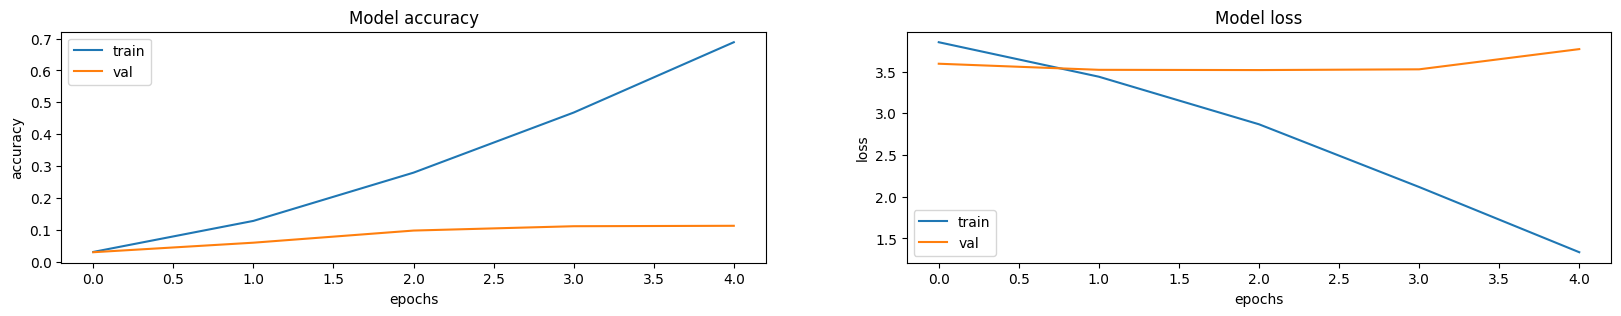

In [7]:
plt.figure(figsize=(20, 3))
for i, metric in enumerate(["accuracy", "loss"]):
    plt.subplot(1, 2, i + 1) 
    plt.plot(model.history.history[metric])
    plt.plot(model.history.history["val_" + metric])
    plt.title("Model {}".format(metric))
    plt.xlabel("epochs")
    plt.ylabel(metric)
    plt.legend(["train", "val"])

test_loss, test_metric = model.evaluate(x_test, y_test, verbose = 1)
print(f"The test loss is {test_loss:.4f}, the test accuracy is {test_metric:.4f}.")

pred = model.predict(x_test)
print("Test Input Shape: {} Test output shape: {}".format(x_test.shape, pred.shape))


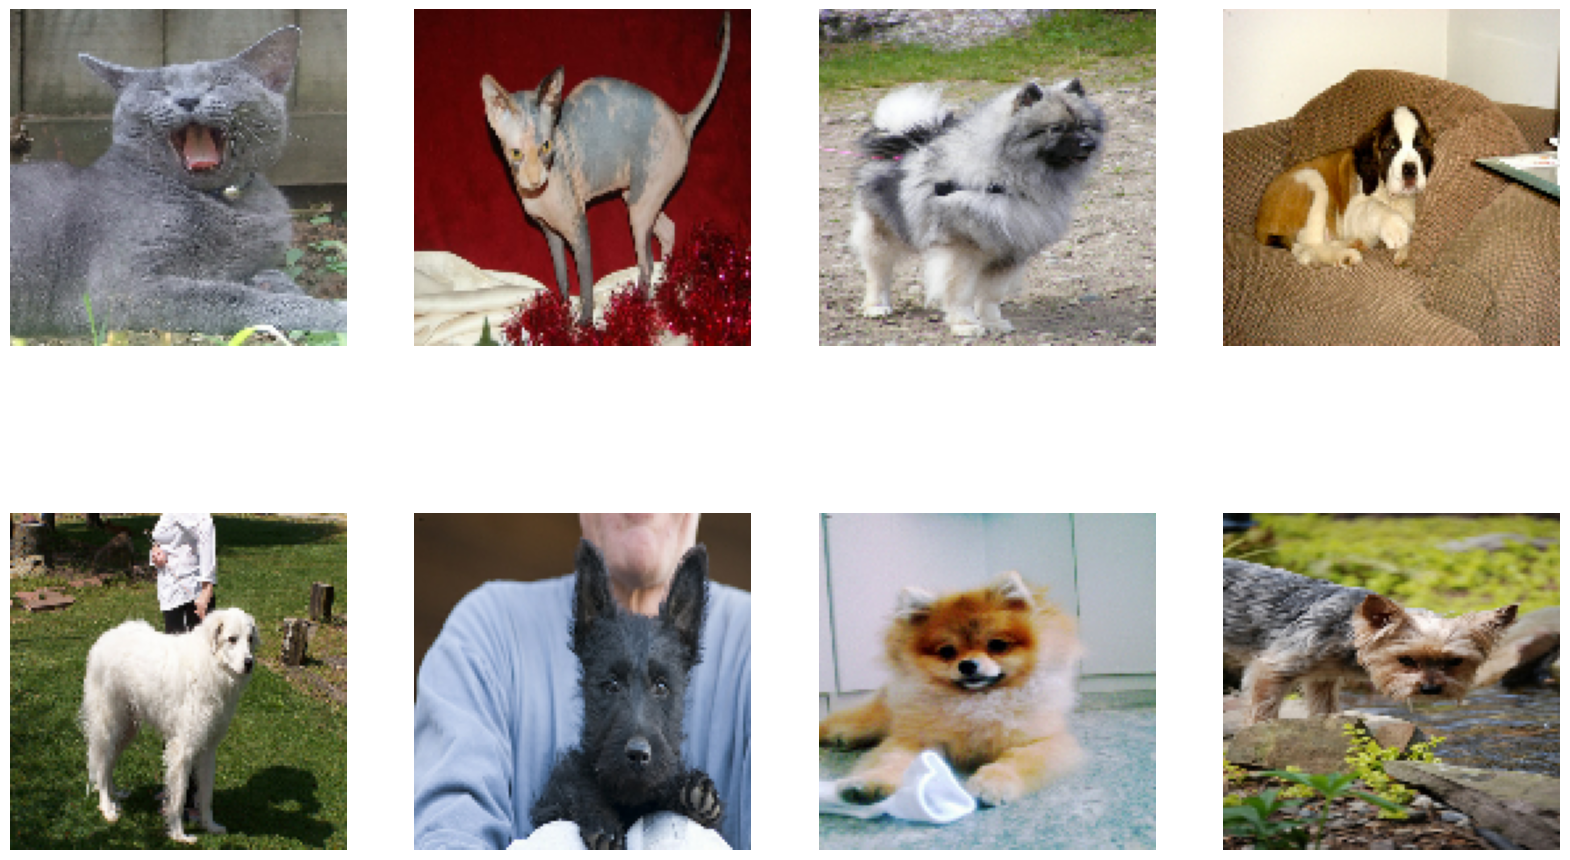

In [ ]:
pred = np.argmax(pred, axis=-1)
y_test = y_test.squeeze()

plt.figure(figsize=(20,12))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    rand_idx = np.random.randint(0, x_test.shape[0])
    plt.axis('off')
    #Qui da errore sul titolo, da mettere a posto
    #plt.title(f"Pred : {labels[pred[rand_idx]]} - GT : {labels[y_test[rand_idx]]}")
    plt.imshow(x_test[rand_idx], cmap="gray")
plt.show()